# LSTM-Based EEG Seizure Detection Demo

This notebook demonstrates autoregressive sequence modeling for EEG seizure detection. It keeps the original experimental outputs while presenting the workflow as a technical portfolio example.

## Overview

The workflow builds an autoregressive LSTM on baseline EEG segments, then uses prediction error as a signal for seizure-like activity. The focus is model construction, error-based detection, and evaluation.

In [ ]:
# iEEG imports
!pip install git+https://github.com/ieeg-portal/ieegpy.git # Install ieegpy toolbox directly from github
from ieeg.auth import Session

# Imports for deep learning
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scientific computing imports
import numpy as np
import scipy as sc
import pandas as pd
from scipy.linalg import hankel
from tqdm import tqdm
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Setup log omitted.
 Cloning https://github.com/ieeg-portal/ieegpy.git to /tmp/pip-req-build-6607zh18
 Running command git clone --filter=blob:none --quiet https://github.com/ieeg-portal/ieegpy.git /tmp/pip-req-build-6607zh18
 Resolved https://github.com/ieeg-portal/ieegpy.git to commit 080bfa42a8503380ef164b5e7b116613f75073bb
 Preparing metadata (setup.py) ... done
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.0/98.0 kB 1.2 MB/s eta 0:00:00
 Created wheel for ieeg: filename=ieeg-1.6-py3-none-any.whl size=27499 sha256=a294182af2a23ee5b57f214f15a520a4921437785f89208a9d8d7ad5078bc46d
 Stored in directory: /tmp/pip-ephem-wheel-cache-9arn585d/wheels/c0/2a/4d/452574b1c3c63e86df54de09161463c0509e9eeffc1aad898e
Successfully built ieeg


In [ ]:
def set_seed(seed):
  np.random.seed(seed)
  torch.manual_seed(seed)
  random.seed(seed)
set_seed(5210)

## Background

This section summarizes why prediction error can separate baseline interictal EEG from ictal activity.

Bhattacharya et al. (2023) present an unsupervised EEG seizure identification approach based on clustering and an LSTM network. The LSTM is trained on interictal EEG segments to forecast future time-series samples. Because the model only sees baseline dynamics during training, seizure segments tend to produce larger prediction errors.

## Autoregressive LSTM Model

A synthetic sinusoidal signal provides a controlled test case for the autoregressive LSTM workflow before applying the same code path to EEG segments.

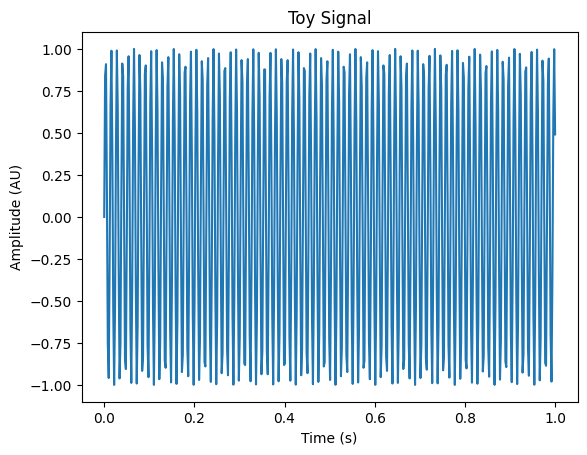

In [ ]:
fs = 500
data_len = 1 # seconds
n_channels = 1
data = np.sin(torch.arange(0,data_len*fs,dtype=torch.float64).expand(n_channels,data_len*fs).T)
# data = torch.arange(0,data_len*fs,dtype=torch.float64).expand(n_channels,data_len*fs).T
sns.lineplot(x=np.linspace(0,1,fs),y=data.squeeze())
plt.ylabel('Amplitude (AU)');
plt.xlabel('Time (s)');
plt.title('Toy Signal');

Autoregression is framed as a sliding-window prediction setup. Each row of the Hankel matrix contains 12 input samples and one target sample, allowing the model to predict the next point from recent history.

### Sequence Windowing

#### Sequence Window Matrix

The Hankel matrix is represented as a PyTorch tensor so it can be passed directly into the sequence model.

In [ ]:
# Create your hankel matrix here...
hankel_matrix = hankel(data[:488], data[487:500]).reshape(488, 13, n_channels)

# Converting to a PyTorch tensor
data_mat = torch.tensor(hankel_matrix, dtype=torch.float64)

# Printing out the dimensions of the tensor
data_mat.shape

torch.Size([488, 13, 1])

#### Input and Target Split

Each sequence is split into a 12-sample input window and a one-sample prediction target. The input tensor keeps the shape expected by PyTorch LSTM layers: sequences, time steps, channels.

In [ ]:
# Prepare input and target data for the model here...
# Please cast your torch.tensors to type float to avoid downstream issues:
# my_tensor = my_tensor.float()
input_data = data_mat[:, :12, :].float()
target_data = data_mat[:, 12, :].squeeze(-1).float()

# Printing out the shapes to verify the dimensions
(input_data.shape, target_data.shape)

(torch.Size([488, 12, 1]), torch.Size([488]))

### Model Definition

The model uses a PyTorch LSTM followed by a linear output layer. This architecture is a compact baseline for one-step prediction on short EEG windows.

#### Data Loader

The input and target tensors are wrapped in a `TensorDataset` and batched with a `DataLoader` for model training.

In [ ]:
# Create DataLoader for training
dataset = TensorDataset(input_data, target_data)
dataloader = DataLoader(dataset, batch_size=100, shuffle=False)

#### LSTM Architecture

The model class defines the LSTM layer, hidden-state size, and final linear projection used to predict the next sample in each sequence.

In [ ]:
# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)  # Renamed to fc for clarity

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        y_pred = self.fc(lstm_out[:, -1, :])
        return y_pred

#### Model Check

The printed model summary confirms the LSTM input size, hidden size, and output layer used for one-step prediction.

In [ ]:
input_size = 1
hidden_size = 100
output_size = 1

model = LSTMModel(input_size, hidden_size, output_size)
print(model)

LSTMModel(
 (lstm): LSTM(1, 100, batch_first=True)
 (fc): Linear(in_features=100, out_features=1, bias=True)
)


#### Training Objective

The training objective is mean squared error between the predicted and true next sample. Adam is used as the optimizer with a small learning rate for stable autoregressive training.

In [ ]:
# Define loss function and optimizer
criterion = nn.MSELoss()

# Creating the Adam optimizer with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

(criterion, optimizer)

(MSELoss(),
 Adam (
 Parameter Group 0
 amsgrad: False
 betas: (0.9, 0.999)
 capturable: False
 differentiable: False
 eps: 1e-08
 foreach: None
 fused: None
 lr: 0.001
 maximize: False
 weight_decay: 0
 ))

### Training Loop

The training loop runs through each epoch, generates next-sample predictions, computes MSE loss, and updates the model weights. Loss is logged periodically to check convergence.

In [ ]:
# Training loop
num_epochs = 100
for epoch in range(num_epochs):

    # Your code here!
    for inputs, targets in dataloader:
      optimizer.zero_grad()
      outputs = model(inputs)
      # Reshape targets to match the output shape
      targets = targets.unsqueeze(1)  # Adds a dimension of size 1 at dimension 1
      loss = criterion(outputs, targets)
      loss.backward()
      optimizer.step()
    if epoch % 10 == 9:
      print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()*10000:.4f}')

Epoch [10/100], Loss: 144.3850
Epoch [20/100], Loss: 0.6563
Epoch [30/100], Loss: 0.0158
Epoch [40/100], Loss: 0.0103
Epoch [50/100], Loss: 0.0098
Epoch [60/100], Loss: 0.0093
Epoch [70/100], Loss: 0.0089
Epoch [80/100], Loss: 0.0084
Epoch [90/100], Loss: 0.0079
Epoch [100/100], Loss: 0.0074


### Prediction Error Analysis

#### Prediction Error Function

After training, each one-second clip is converted into a sequence of squared prediction errors. Larger errors indicate portions of the signal that differ from the baseline dynamics learned by the model.

In [ ]:
def get_mse_values(model, input_clip):
    # Preprocess the input clip
    hankel_matrix = hankel(input_clip[:488], input_clip[487:500]).reshape(488, 13)
    input_data = torch.tensor(hankel_matrix, dtype=torch.float32)[:, :12].unsqueeze(-1)
    target_data = torch.tensor(hankel_matrix, dtype=torch.float32)[:, 12]

    # Create a new DataLoader with batch size 1
    dataset = TensorDataset(input_data, target_data)
    dataloader = DataLoader(dataset, batch_size=1)

    mse_values = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            squared_error = (outputs.squeeze() - targets) ** 2
            mse_values.append(squared_error.item())

    return np.array(mse_values)

#### Prediction Visualization

A companion prediction function returns the model output for each sliding window, making it possible to compare predicted and observed signal values.

In [ ]:
def get_predictions(model, input_clip):
    # Preprocess the input clip
    hankel_matrix = hankel(input_clip[:488], input_clip[487:500]).reshape(488, 13)
    input_data = torch.tensor(hankel_matrix, dtype=torch.float32)[:, :12].unsqueeze(-1)

    # Create a new DataLoader with batch size 1
    dataset = TensorDataset(input_data)
    dataloader = DataLoader(dataset, batch_size=1)

    predictions = []
    with torch.no_grad():
        for inputs in dataloader:
            inputs = inputs[0]
            outputs = model(inputs)
            predictions.append(outputs.squeeze().item())

    return np.array(predictions)

#### Training Error Distribution

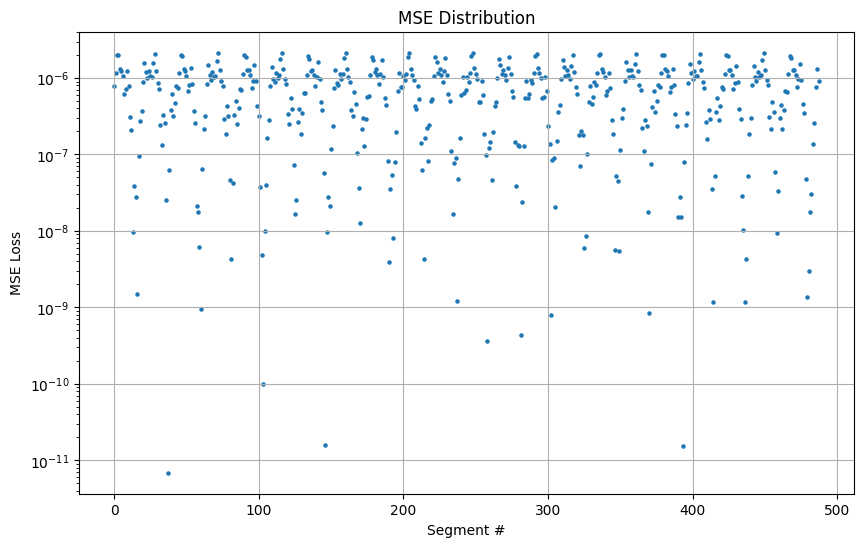

In [ ]:
# Generate MSE values for the training data
mse_values = get_mse_values(model, data.squeeze().numpy())

# Create a scatter plot of the MSE distribution
plt.figure(figsize=(10, 6))
plt.scatter(range(len(mse_values)), mse_values, s=5)
plt.xlabel('Segment #')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.title('MSE Distribution')
plt.grid(True)
plt.show()

#### Threshold-Based Detection Example

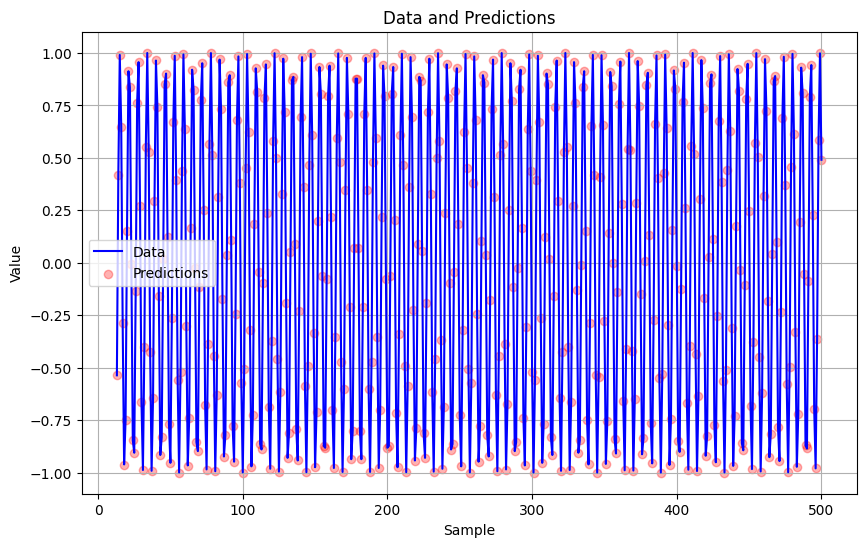

In [ ]:
# Generate predictions for samples from x13 to x500
predictions = get_predictions(model, data.squeeze().numpy())

# Create a plot with data values and overlaid predictions
plt.figure(figsize=(10, 6))
plt.plot(range(13, 501), data.squeeze().numpy()[12:], color='blue', label='Data')
plt.scatter(range(13, 501), predictions, color='red', alpha=0.3, label='Predictions')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Data and Predictions')
plt.legend()
plt.grid(True)
plt.show()

## 2. Seizure detection

In [ ]:
# Resetting the seed for the next section!
set_seed(5210)

### Sequence Windowing

The EEG example uses one seizure-onset channel from an implanted intracranial recording. The objective is clip-level seizure detection from baseline-trained autoregressive prediction error.

#### Seizure Metadata

The seizure timing table contains onset, offset, and matched interictal windows used to construct the EEG evaluation clips.

In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame
seizure_times = pd.read_csv('HUP235_seizure_times.csv')

# Display the DataFrame
print(seizure_times)

 Patient iEEG_ID Onset Offset Interictal
0 HUP235 HUP235_phaseII 107374.2078 107391.19 78574.8000
1 HUP235 HUP235_phaseII 107486.3563 107502.68 78686.3563
2 HUP235 HUP235_phaseII 107754.7900 107775.34 78954.7900
3 HUP235 HUP235_phaseII 116324.6629 116344.79 87524.6629
4 HUP235 HUP235_phaseII 116938.2674 116955.89 88135.5000
5 HUP235 HUP235_phaseII 126735.8514 126757.97 97946.0000
6 HUP235 HUP235_phaseII 170199.3292 170236.93 141376.8600
7 HUP235 HUP235_phaseII 255438.0300 255453.80 226640.1600
8 HUP235 HUP235_phaseII 293234.5401 293337.74 264473.8300
9 HUP235 HUP235_phaseII 497084.3746 497216.20 468284.3746
10 HUP235 HUP235_phaseII 513176.0496 513306.27 484401.4700


#### Example Clip Visualization

The first seizure interval is compared with a matched interictal recording from the same channel. The paired plots provide a visual check of baseline and seizure morphology before model training.

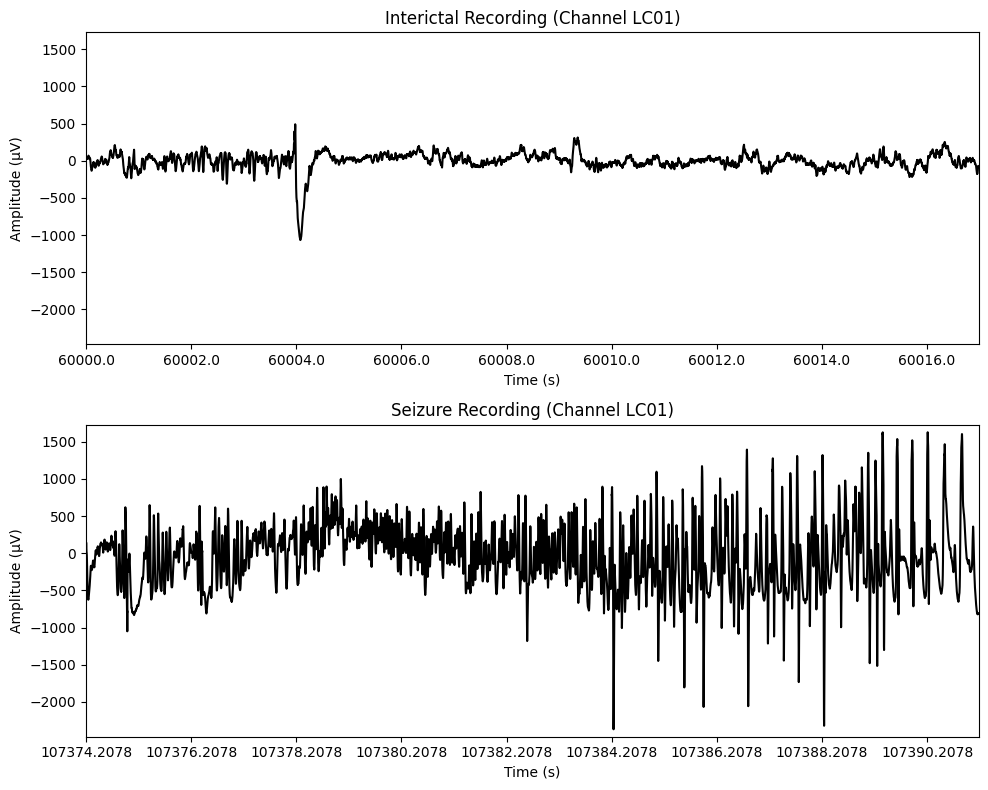

In [ ]:
# Open the dataset
with open('ieeg_login.bin', 'r') as f:
    session = Session('your_ieeg_username', f.read())
dataset = session.open_dataset('sample_ieeg_dataset')

# Get the channel labels
channel_labels = dataset.get_channel_labels()

# Find the index of channel 'LC01'
lc01_index = channel_labels.index('LC01')

# Get the first seizure from the DataFrame
seizure = seizure_times.iloc[0]

# Calculate the duration of the seizure
seizure_duration = int((seizure['Offset'] - seizure['Onset']) * 1e6)

# Get the interictal start time
interictal_start = 60000

# Get the interictal and seizure data for channel LC01 using the index
interictal_data = dataset.get_data(interictal_start * 1e6, seizure_duration, [lc01_index])
seizure_data = dataset.get_data(int(seizure['Onset'] * 1e6), seizure_duration, [lc01_index])

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot the interictal data
interictal_time = np.arange(interictal_start, interictal_start + seizure_duration / 1e6, 1/dataset.get_time_series_details(dataset.get_channel_labels()[0]).sample_rate)
ax1.plot(interictal_time, interictal_data, color='black')
ax1.set_title('Interictal Recording (Channel LC01)')
ax1.set_ylabel('Amplitude (μV)')
ax1.set_xlim(interictal_start, interictal_start + seizure_duration / 1e6)
ax1.set_xticks(np.arange(interictal_start, interictal_start + seizure_duration / 1e6, 2))  # Set x-ticks every 2 seconds
ax1.set_xticklabels(np.arange(interictal_start, interictal_start + seizure_duration / 1e6, 2))  # Set x-tick labels
ax1.set_xlabel('Time (s)')

# Plot the seizure data
seizure_time = np.arange(seizure['Onset'], seizure['Offset'], 1/dataset.get_time_series_details(dataset.get_channel_labels()[0]).sample_rate)
ax2.plot(seizure_time, seizure_data, color='black')
ax2.set_title('Seizure Recording (Channel LC01)')
ax2.set_ylabel('Amplitude (μV)')
ax2.set_xlim(seizure['Onset'], seizure['Offset'])
ax2.set_xticks(np.arange(seizure['Onset'], seizure['Offset'], 2))  # Set x-ticks every 2 seconds
ax2.set_xticklabels(np.arange(seizure['Onset'], seizure['Offset'], 2))  # Set x-tick labels
ax2.set_xlabel('Time (s)')

# Set the y-axis limits to be the same for both subplots
y_min = min(np.min(interictal_data) - 100, np.min(seizure_data) - 100)
y_max = max(np.max(interictal_data) + 100, np.max(seizure_data) + 100)
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# Adjust the spacing between subplots
plt.tight_layout()

# Display the plot
plt.show()

#### Epileptiform Spike Context

A spike-like event in the interictal training window can make the baseline model less specific, because the model may learn activity that resembles short epileptic discharges.

An epileptiform spike window may be used to train an autoregressive seizure detection algorithm, which could result in less than ideal results and more false positives. Brief, localized discharges known as epileptiform spikes are characterized by coordinated neuronal firing, a feature shared by seizure activity. The system may mistakenly categorize non-seizure segments containing spikes as seizures during inference if it learns to correlate these spikes with seizures during training. This might lead to a higher rate of false alarms and decreased specificity.

### Model Definition

The same autoregressive LSTM architecture is reused on real EEG data. The interictal training segment provides the baseline dynamics for later seizure detection.

#### EEG Training Window

The interictal signal is downsampled to 512 Hz and converted into a Hankel matrix with 12 input samples and 1 target sample.

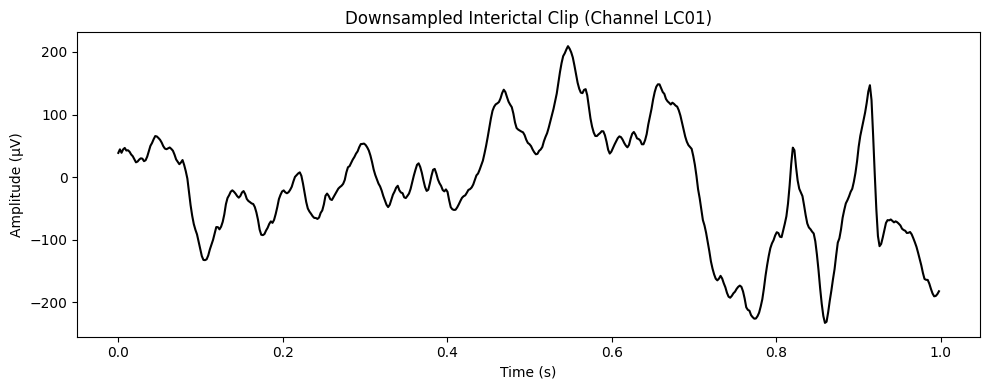

Shape of the Hankel matrix: (500, 13, 1)


In [ ]:
from scipy.signal import decimate

# Extract the first second of the interictal clip starting at 60000 seconds
interictal_start = 60000
interictal_duration = 1  # in seconds
interictal_data = dataset.get_data(interictal_start * 1e6, interictal_duration * 1e6, [lc01_index]).flatten()

# Downsample the interictal clip by a factor of 2
downsampled_data = decimate(interictal_data, 2)

# Build a Hankel matrix for channel LC01 based on 12 input samples and 1 output sample
hankel_matrix = hankel(downsampled_data[:500], downsampled_data[499:512]).reshape(500, 13, 1)

# Plot the downsampled EEG clip
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(downsampled_data)) / 512, downsampled_data, color='black')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (μV)')
plt.title('Downsampled Interictal Clip (Channel LC01)')
plt.tight_layout()
plt.show()

# Print the shape of the Hankel matrix
print("Shape of the Hankel matrix:", hankel_matrix.shape)

#### EEG Training Segment

The interictal clip is converted into overlapping input-target windows, batched, and used to train a new LSTM model for this channel.

In [ ]:
# Prepare input and target data for the LSTM
data_mat = torch.tensor(hankel_matrix, dtype=torch.float64)

input_data = data_mat[:, :12, :].float()
target_data = data_mat[:, 12, :].squeeze(-1).float()

In [ ]:
# Initialize the model
dataset = TensorDataset(input_data, target_data)
dataloader = DataLoader(dataset, batch_size=100, shuffle=False)

input_size = 1
hidden_size = 100
output_size = 1

model = LSTMModel(input_size, hidden_size, output_size)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training loop
num_epochs = 100
for epoch in range(num_epochs):

    # Your code here!
    for inputs, targets in dataloader:
      optimizer.zero_grad()
      outputs = model(inputs)
      # Reshape targets to match the output shape
      targets = targets.unsqueeze(1)  # Adds a dimension of size 1 at dimension 1
      loss = criterion(outputs, targets)
      loss.backward()
      optimizer.step()
    if epoch % 10 == 9:
      print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 12079.2627
Epoch [20/100], Loss: 11316.1699
Epoch [30/100], Loss: 10563.7578
Epoch [40/100], Loss: 9852.6572
Epoch [50/100], Loss: 9206.7002
Epoch [60/100], Loss: 8540.9316
Epoch [70/100], Loss: 8012.3799
Epoch [80/100], Loss: 7467.0317
Epoch [90/100], Loss: 6918.4351
Epoch [100/100], Loss: 6473.7812


### Training Loop

#### Matched Ictal and Interictal Clips

A one-second ictal clip and a matched one-second interictal clip are extracted from the same recording channel.

In [ ]:
# Open the dataset
dataset = session.open_dataset('sample_ieeg_dataset')

# Get the channel labels
channel_labels = dataset.get_channel_labels()

# Find the index of channel 'LC01'
lc01_index = channel_labels.index('LC01')

# Get the first seizure from the DataFrame
seizure = seizure_times.iloc[0]

# Get the first second of the seizure
seizure_start = seizure['Onset']
seizure_duration = 1  # in seconds
seizure_data = dataset.get_data(int(seizure_start * 1e6), int(seizure_duration * 1e6), [lc01_index]).flatten()

# Get 1 second of interictal data starting at the given interictal time
interictal_start = seizure['Interictal']
interictal_duration = 1  # in seconds
interictal_data = dataset.get_data(int(interictal_start * 1e6), int(interictal_duration * 1e6), [lc01_index]).flatten()

#### Prediction Error Distributions

The trained model is applied to the training, interictal, and ictal clips to compare MSE distributions.

In [ ]:
def get_mse_values(model, input_clip):
    # Preprocess the input clip
    hankel_matrix = hankel(input_clip[:500], input_clip[499:512]).reshape(500, 13)
    input_data = torch.tensor(hankel_matrix, dtype=torch.float32)[:, :12].unsqueeze(-1)
    target_data = torch.tensor(hankel_matrix, dtype=torch.float32)[:, 12]

    # Create a new DataLoader with batch size 1
    dataset = TensorDataset(input_data, target_data)
    dataloader = DataLoader(dataset, batch_size=1)

    mse_values = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            squared_error = (outputs.squeeze() - targets) ** 2
            mse_values.append(squared_error.item())

    return np.array(mse_values)

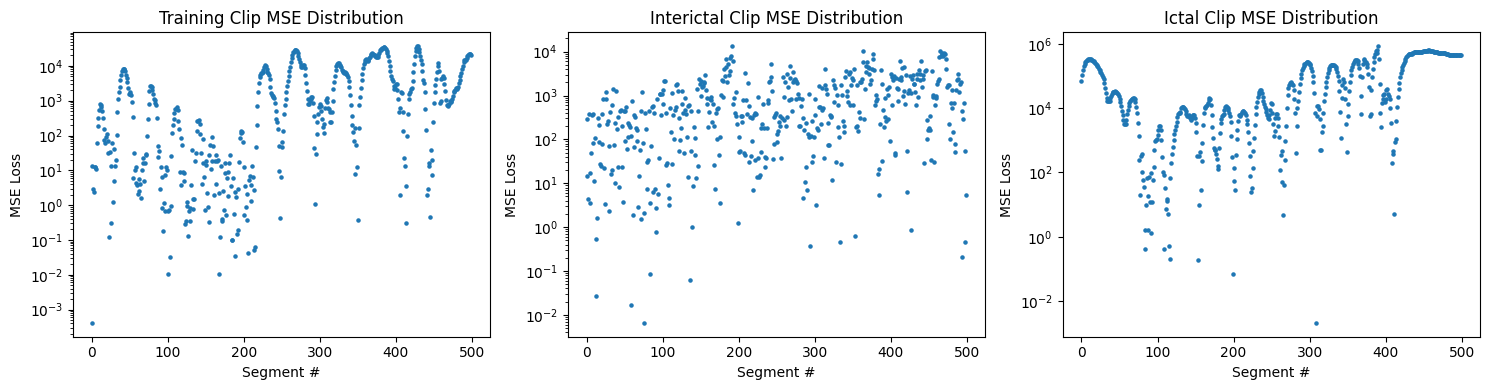

In [ ]:
# Downsample the interictal and ictal clips to match the sampling rate of the training clip
interictal_data_downsampled = decimate(interictal_data, 2)
seizure_data_downsampled = decimate(seizure_data, 2)

# Calculate MSE values for each clip using the get_mse_values function from section 1
training_mse = get_mse_values(model, downsampled_data)
interictal_mse = get_mse_values(model, interictal_data_downsampled)
ictal_mse = get_mse_values(model, seizure_data_downsampled)

# Plot the MSE distributions for each clip
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.scatter(range(len(training_mse)), training_mse, s=5)
ax1.set_title('Training Clip MSE Distribution')
ax1.set_xlabel('Segment #')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')

ax2.scatter(range(len(interictal_mse)), interictal_mse, s=5)
ax2.set_title('Interictal Clip MSE Distribution')
ax2.set_xlabel('Segment #')
ax2.set_ylabel('MSE Loss')
ax2.set_yscale('log')

ax3.scatter(range(len(ictal_mse)), ictal_mse, s=5)
ax3.set_title('Ictal Clip MSE Distribution')
ax3.set_xlabel('Segment #')
ax3.set_ylabel('MSE Loss')
ax3.set_yscale('log')

plt.tight_layout()
plt.show()

#### Signal, Error, and Threshold Comparison

The plots compare downsampled ictal/interictal clips, sequence-wise loss, and log-transformed squared-error distributions with an interictal threshold.

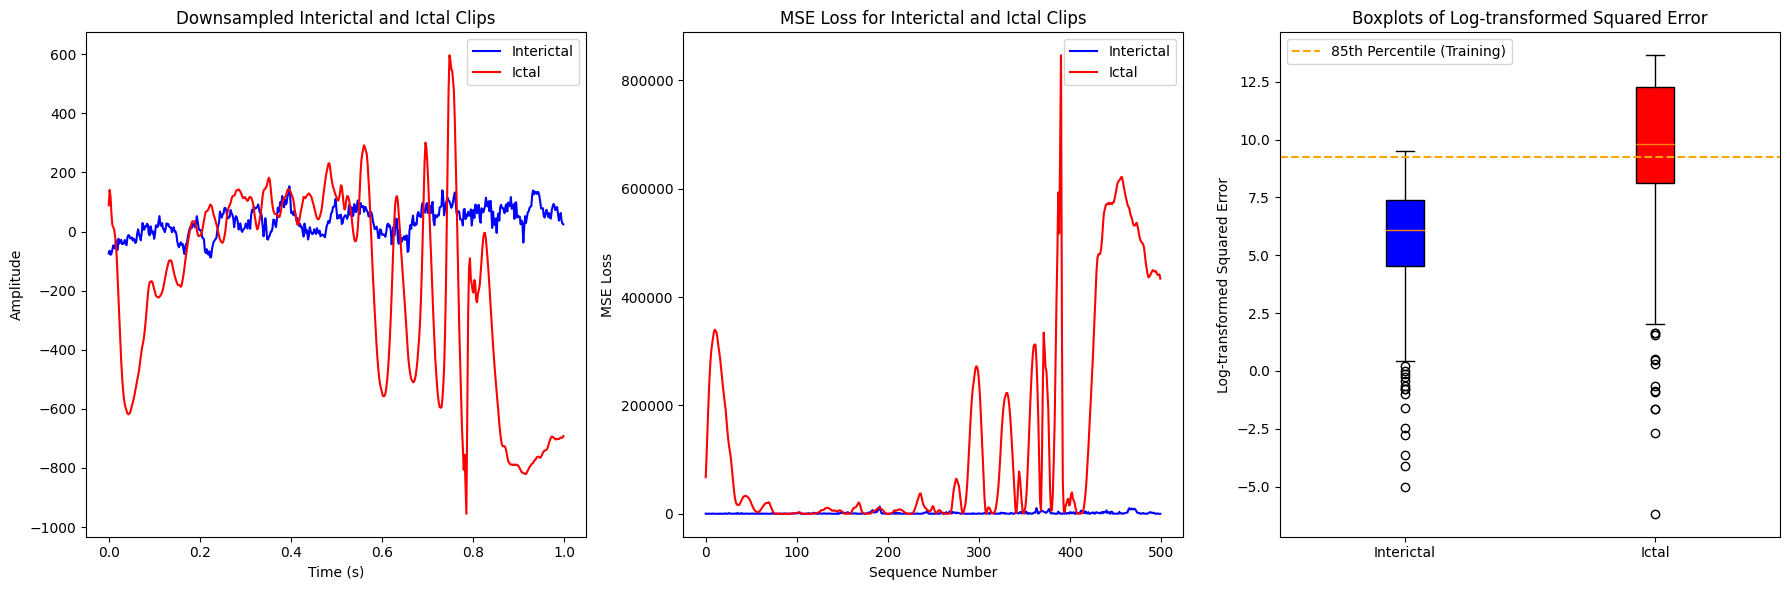

In [ ]:
# Downsample the interictal and ictal clips to match the sampling rate of the training clip
interictal_data_downsampled = decimate(interictal_data, 2)
ictal_data_downsampled = decimate(seizure_data, 2)

# Calculate MSE values for each clip using the get_mse_values function from section 1
training_mse = get_mse_values(model, downsampled_data)
interictal_mse = get_mse_values(model, interictal_data_downsampled)
ictal_mse = get_mse_values(model, ictal_data_downsampled)

# Create a figure with three subplots (1 row, 3 columns) and adjust the figure size to 18 x 6 (W x H)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot the downsampled interictal and ictal clips in the first subplot
ax1.plot(np.arange(len(interictal_data_downsampled)) / 512, interictal_data_downsampled, color='blue', label='Interictal')
ax1.plot(np.arange(len(ictal_data_downsampled)) / 512, ictal_data_downsampled, color='red', label='Ictal')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Downsampled Interictal and Ictal Clips')
ax1.legend()

# Plot the MSE values for each clip in the second subplot
ax2.plot(range(len(interictal_mse)), interictal_mse, color='blue', label='Interictal')
ax2.plot(range(len(ictal_mse)), ictal_mse, color='red', label='Ictal')
ax2.set_xlabel('Sequence Number')
ax2.set_ylabel('MSE Loss')
ax2.set_title('MSE Loss for Interictal and Ictal Clips')
ax2.legend()

# Create boxplots of the log-transformed squared error for interictal and ictal clips in the third subplot
log_interictal_mse = np.log(interictal_mse)
log_ictal_mse = np.log(ictal_mse)
bp = ax3.boxplot([log_interictal_mse, log_ictal_mse], labels=['Interictal', 'Ictal'], patch_artist=True)
colors = ['blue', 'red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax3.set_ylabel('Log-transformed Squared Error')
ax3.set_title('Boxplots of Log-transformed Squared Error')

# Add an orange horizontal line at the 85th percentile of the loss on the training interictal clip
percentile_85 = np.percentile(training_mse, 85)
ax3.axhline(np.log(percentile_85), color='orange', linestyle='--', label='85th Percentile (Training)')
ax3.legend()

plt.tight_layout()
plt.show()

The prediction-error distribution shows a clear separation between baseline-like and seizure-like clips, making MSE a useful detection feature.

### Prediction Error Analysis

A simple threshold classifier is used for demonstration: the 85th percentile of interictal training loss defines the decision boundary. Clips with higher mean prediction error are labeled ictal.

#### Clip-Level Classifier

The classifier converts a one-second EEG clip into a mean prediction-error score and compares it with the interictal threshold.

In [ ]:
def predict_ictal_interictal(model, input_clip, threshold):
    # Calculate MSE values for each segment in the input clip
    mse_values = get_mse_values(model, input_clip)

    # Compute the mean MSE value across the entire clip
    mean_mse = np.mean(mse_values)

    # Compare the mean MSE value with the decision threshold
    if mean_mse > threshold:
        return "Ictal"
    else:
        return "Interictal"

# Calculate the 85th percentile of interictal loss from the training clip
threshold = percentile_85

# Make a prediction on the ictal clip
ictal_prediction = predict_ictal_interictal(model, ictal_data_downsampled, threshold)

print("Prediction for the ictal clip:", ictal_prediction)

Prediction for the ictal clip: Ictal


A balanced ictal/interictal evaluation set is used here to measure model behavior. In deployment, seizure clips would be much rarer than non-seizure clips, so precision and false-positive rate would need extra attention.

Balanced evaluation is useful for a compact demo, but it does not reflect real seizure prevalence. In deployment, interictal clips would dominate, so precision, false-positive rate, temporal context, and patient-level variability would need stricter validation.

#### Evaluation Clip Construction

Seizure and matched interictal intervals are segmented into one-second clips. Each seizure is rounded down to complete one-second windows before feature extraction.

In [ ]:
# Open the dataset
dataset = session.open_dataset('sample_ieeg_dataset')

# Get the channel labels
channel_labels = dataset.get_channel_labels()

# Find the index of channel 'LC01'
lc01_index = channel_labels.index('LC01')

# Initialize empty lists to store the ictal and interictal clips
ictal_clips = []
interictal_clips = []

# Iterate through each seizure in the table
for _, row in seizure_times.iterrows():
    # Calculate the duration of the seizure and round down to the nearest integer
    seizure_duration = int(row['Offset'] - row['Onset'])

    # Pull the ictal data for the seizure
    ictal_data = dataset.get_data(row['Onset'] * 1e6, seizure_duration * 1e6, [lc01_index]).flatten()

    # Pull the interictal data with the same duration starting at the given 'Interictal' time
    interictal_data = dataset.get_data(row['Interictal'] * 1e6, seizure_duration * 1e6, [lc01_index]).flatten()

    # Downsample the ictal and interictal data to 512 Hz
    ictal_data_downsampled = decimate(ictal_data, 2)
    interictal_data_downsampled = decimate(interictal_data, 2)

    # Split the ictal and interictal data into 1-second clips
    ictal_clips.extend(np.split(ictal_data_downsampled, seizure_duration))
    interictal_clips.extend(np.split(interictal_data_downsampled, seizure_duration))

# Convert the ictal and interictal clips to matrices
ictal_matrix = np.vstack(ictal_clips)
interictal_matrix = np.vstack(interictal_clips)

print("Ictal matrix shape:", ictal_matrix.shape)
print("Interictal matrix shape:", interictal_matrix.shape)

Ictal matrix shape: (527, 512)
Interictal matrix shape: (527, 512)


Ictal and interictal clip matrices are stacked into a single evaluation matrix, with labels encoded as 1 for ictal and 0 for interictal.

In [ ]:
# Combine the ictal and interictal matrices into a single matrix
combined_matrix = np.vstack((ictal_matrix, interictal_matrix))

# Create a vector of target labels (1 for ictal, 0 for interictal)
target_labels = np.hstack((np.ones(ictal_matrix.shape[0]), np.zeros(interictal_matrix.shape[0])))

print("Combined matrix shape:", combined_matrix.shape)
print("Target labels shape:", target_labels.shape)

Combined matrix shape: (1054, 512)
Target labels shape: (1054,)


#### Batch Prediction

The trained model scores each evaluation clip. Progress tracking is useful because clip-level autoregressive prediction can be slow without GPU acceleration.

In [ ]:
# Create a list to store the predictions
predictions = []

# Iterate over each clip in the combined matrix and generate predictions
for clip in tqdm(combined_matrix):

    # Flatten the clip to match the input shape expected by the model
    clip = clip.flatten()

    # Generate prediction for the clip using the predict_ictal_interictal function
    prediction = predict_ictal_interictal(model, clip, threshold)

    # Append the prediction to the list
    predictions.append(prediction)

# Convert the predictions list to a NumPy array
predictions = np.array(predictions)

# Print the total number of predictions
print("Total predictions:", len(predictions))

100%|██████████| 1054/1054 [05:32<00:00, 3.17it/s]

Total predictions: 1054


The final evaluation reports accuracy, precision, recall, and a confusion matrix. These metrics separate sensitivity to seizures from false positives on interictal clips.

Accuracy: 0.9250474383301708
Precision: 0.872093023255814
Recall: 0.9962049335863378


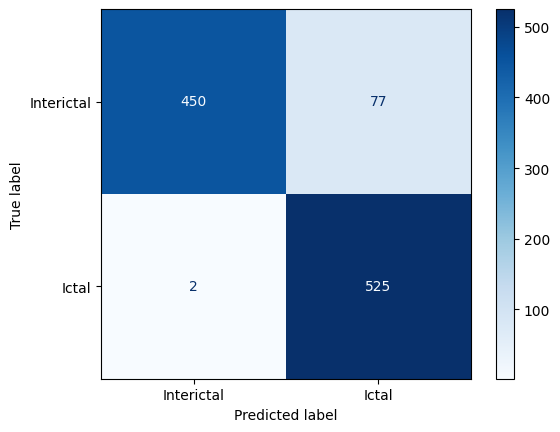

In [ ]:
# Convert the predictions to binary labels (0 for interictal, 1 for ictal)
binary_predictions = np.array([1 if pred == 'Ictal' else 0 for pred in predictions])

# Calculate accuracy
accuracy = np.mean(binary_predictions == target_labels)

# Calculate precision
precision = precision_score(target_labels, binary_predictions)

# Calculate recall
recall = recall_score(target_labels, binary_predictions)

# Print the evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Compute the confusion matrix
cm = confusion_matrix(target_labels, binary_predictions)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Interictal', 'Ictal'])
disp.plot(cmap='Blues')
plt.show()

The confusion matrix indicates strong seizure sensitivity, while some interictal clips are still classified as seizure-like. This pattern is expected when baseline EEG contains sharp transients or activity near the seizure onset zone.

The confusion matrix suggests high sensitivity with lower specificity. Some interictal clips are classified as seizure-like, likely because sharp transients or epileptiform discharges increase autoregressive prediction error.

### EEG Segment Classification Extension

The extension explores a modified unsupervised detection strategy using the same held-out evaluation set. The emphasis is higher precision with limited training data and modest computational cost.

This extension tests whether a higher-capacity LSTM autoencoder-style detector improves precision. The variant adds model capacity, dropout regularization, RMSprop optimization, and longer training while keeping the same prediction-error evaluation idea.

In [ ]:
# Extract the first second of the interictal clip starting at 60010 seconds
interictal_start = 60000
interictal_duration = 1  # in seconds
dataset = session.open_dataset('sample_ieeg_dataset')
interictal_data = dataset.get_data(interictal_start * 1e6, interictal_duration * 1e6, [lc01_index]).flatten()

# Downsample the interictal clip by a factor of 2
downsampled_data = decimate(interictal_data, 2)

# Build a Hankel matrix for channel LC01 based on 12 input samples and 1 output sample
hankel_matrix = hankel(downsampled_data[:500], downsampled_data[499:512]).reshape(500, 13, 1)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Prepare input and target data for the LSTM
data_mat = torch.tensor(hankel_matrix, dtype=torch.float64)
input_data = data_mat[:, :12, :].float()
target_data = data_mat[:, 12, :].squeeze(-1).float()

# Initialize the model
dataset = TensorDataset(input_data, target_data)
dataloader = DataLoader(dataset, batch_size=100, shuffle=False)

# Initialize the model with updated hyperparameters
input_size = 1
hidden_size = 200
num_layers = 2
output_size = 1
dropout = 0.2

model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.01)

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    for inputs, targets in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        targets = targets.unsqueeze(1)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 9:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/200], Loss: 4296.8145
Epoch [20/200], Loss: 2472.2610
Epoch [30/200], Loss: 1436.4258
Epoch [40/200], Loss: 902.3181
Epoch [50/200], Loss: 586.0105
Epoch [60/200], Loss: 406.5708
Epoch [70/200], Loss: 296.1409
Epoch [80/200], Loss: 175.9086
Epoch [90/200], Loss: 147.2575
Epoch [100/200], Loss: 156.1957
Epoch [110/200], Loss: 102.0164
Epoch [120/200], Loss: 174.1504
Epoch [130/200], Loss: 66.5008
Epoch [140/200], Loss: 755.5062
Epoch [150/200], Loss: 78.9461
Epoch [160/200], Loss: 98.2572
Epoch [170/200], Loss: 78.5831
Epoch [180/200], Loss: 146.9103
Epoch [190/200], Loss: 113.1457
Epoch [200/200], Loss: 86.3994


In [ ]:
# Create a list to store the predictions
predictions = []

# Iterate over each clip in the combined matrix and generate predictions
for clip in tqdm(combined_matrix):
    # Flatten the clip to match the input shape expected by the model
    clip = clip.flatten()

    # Generate prediction for the clip using the predict_ictal_interictal function
    prediction = predict_ictal_interictal(model, clip, threshold)

    # Append the prediction to the list
    predictions.append(prediction)

# Convert the predictions list to a NumPy array
predictions = np.array(predictions)

100%|██████████| 1054/1054 [15:30<00:00, 1.13it/s]


Accuracy: 0.9468690702087287
Precision: 0.9305301645338209
Recall: 0.9658444022770398


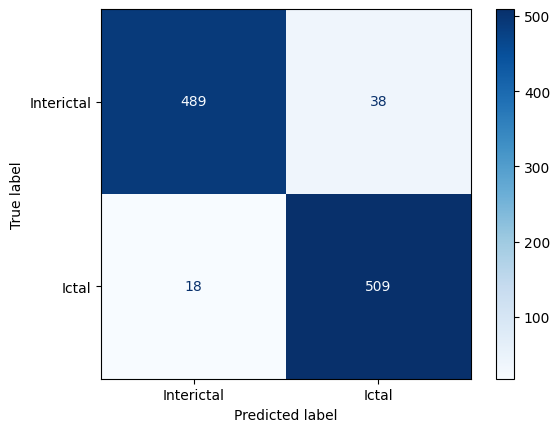

In [ ]:
# Convert the predictions to binary labels (0 for interictal, 1 for ictal)
binary_predictions = np.array([1 if pred == 'Ictal' else 0 for pred in predictions])

# Calculate accuracy
accuracy = np.mean(binary_predictions == target_labels)

# Calculate precision
precision = precision_score(target_labels, binary_predictions)

# Calculate recall
recall = recall_score(target_labels, binary_predictions)

# Print the evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Compute the confusion matrix
cm = confusion_matrix(target_labels, binary_predictions)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Interictal', 'Ictal'])
disp.plot(cmap='Blues')
plt.show()